# Basic RNNs

In [6]:
filepath = tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".",
    extract=True
)
if "_extracted" in filepath:
    ridership_path = Path(filepath) / "ridership"
else:
    ridership_path = Path(filepath).with_name("ridership")

108512/108512 [==============================] - 0s 0us/step


In [7]:
import pandas as pd
from pathlib import Path

path = ridership_path / "CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [8]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

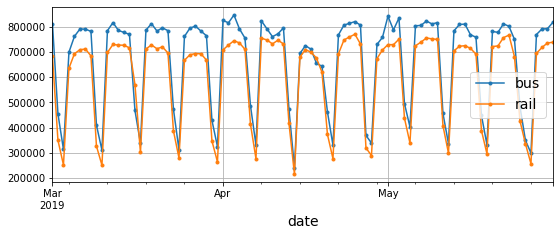

In [9]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
save_fig("daily_ridership_plot")  # extra code – saves the figure for the book
plt.show()

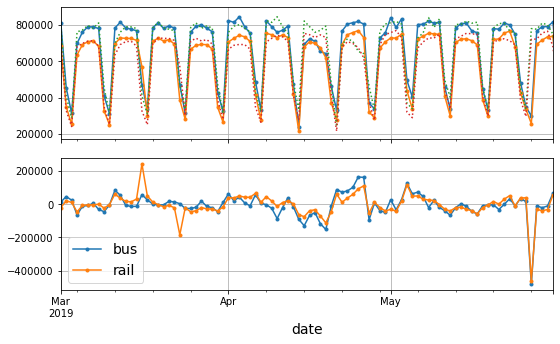

In [10]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot
save_fig("differencing_plot")  # extra code – saves the figure for the book
plt.show()

In [11]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

Mean absolute error (MAE), also called mean absolute deviation (MAD):

In [12]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

Mean absolute percentage error (MAPE):

In [13]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Now let's look at the yearly seasonality and the long-term trends:

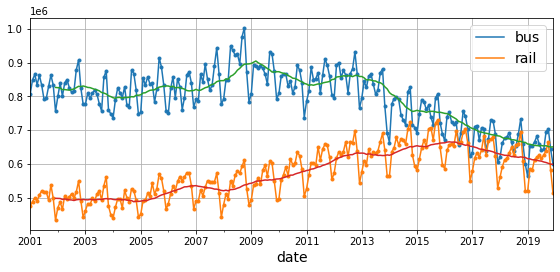

In [14]:
period = slice("2001", "2019")
try:
    df_monthly = df.select_dtypes(include="number").resample('ME').mean()  # compute the mean for each month
    rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
except ValueError as ex:
    try:
        df_monthly = df.select_dtypes(include="number").resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
    except ValueError as ex:
        df_monthly = df.resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
save_fig("long_term_ridership_plot")  # extra code – saves the figure for the book
plt.show()

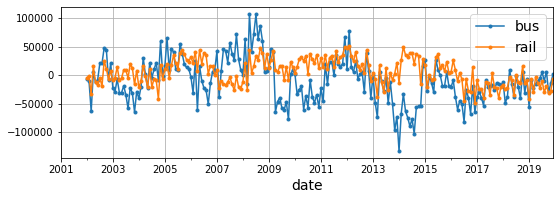

In [15]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
save_fig("yearly_diff_plot")  # extra code – saves the figure for the book
plt.show()

If running on Colab or Kaggle, install the statsmodels library:

In [16]:
if "google.colab" in sys.modules:
    %pip install -q -U statsmodels

In [17]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast()  # returns 427,758.6

In [18]:
y_pred[0]  # ARIMA forecast

427758.62631318445

In [19]:
df["rail"].loc["2019-06-01"]  # target value

379044

In [20]:
df["rail"].loc["2019-05-25"]  # naive forecast (value from one week earlier)

426932

**Warning**: Accessing Pandas `Series` by index directly is deprecated, so I replaced `model.forecast()[0]` with `model.forecast().iloc[0]`:

In [21]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()  # returns 32,040.7

In [22]:
mae

32040.72008847262

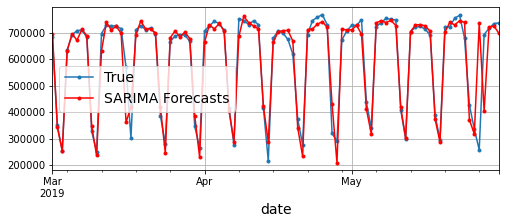

In [23]:
# extra code – displays the SARIMA forecasts
fig, ax = plt.subplots(figsize=(8, 3))
rail_series.loc[time_period].plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")
plt.legend()
plt.show()

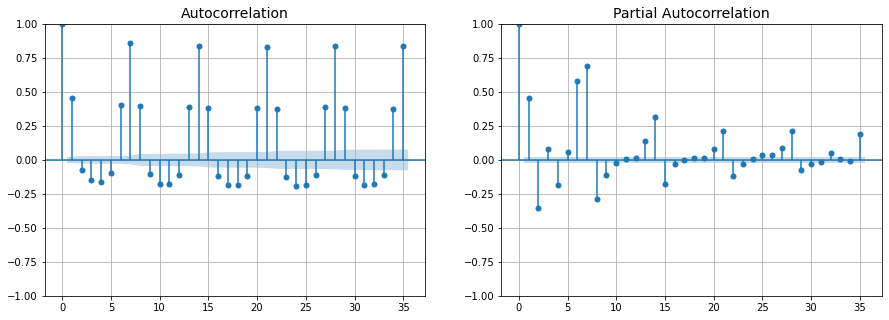

In [24]:
# extra code – shows how to plot the Autocorrelation Function (ACF) and the
#              Partial Autocorrelation Function (PACF)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()
plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

In [25]:
import tensorflow as tf

my_series = [0, 1, 2, 3, 4, 5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    my_series,
    targets=my_series[3:],  # the targets are 3 steps into the future
    sequence_length=3,
    batch_size=2
)
list(my_dataset)

2022-02-17 19:19:46.679147: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [26]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift=1):
    for element in window_dataset:
        print(f"{element}", end=" ")
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


2022-02-17 19:19:46.784180: W tensorflow/core/framework/dataset.cc:744] Input of Window will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


In [27]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
    print(f"{window_tensor}")

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [28]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

In [29]:
dataset = to_windows(tf.data.Dataset.range(6), 4)
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>)]

Before we continue looking at the data, let's split the time series into three periods, for training, validation and testing. We won't look at the test data for now:

In [30]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

In [31]:
seq_length = 56
tf.random.set_seed(42)  # extra code – ensures reproducibility
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [32]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[seq_length])
])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae", patience=50, restore_best_weights=True)
opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
history = model.fit(train_ds, validation_data=valid_ds, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500
33/33 [==============================] - 0s 5ms/step - loss: 0.0098 - mae: 0.1118 - val_loss: 0.0071 - val_mae: 0.0966
Epoch 2/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0070 - mae: 0.0883 - val_loss: 0.0052 - val_mae: 0.0768
Epoch 3/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0059 - mae: 0.0796 - val_loss: 0.0050 - val_mae: 0.0741
Epoch 4/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0055 - mae: 0.0761 - val_loss: 0.0049 - val_mae: 0.0732
Epoch 5/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0054 - mae: 0.0749 - val_loss: 0.0043 - val_mae: 0.0666
Epoch 6/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0051 - mae: 0.0724 - val_loss: 0.0041 - val_mae: 0.0638
Epoch 7/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0047 - mae: 0.0696 - val_loss: 0.0040 - val_mae: 0.0615
Epoch 8/500
33/33 [==============================] - 0s 3ms/step - loss: 0.0051 - m

In [33]:
# extra code – evaluates the model
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

3/3 [==============================] - 0s 2ms/step - loss: 0.0022 - mae: 0.0379


37866.38006567955

## Using a Simple RNN

In [34]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

In [35]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [36]:
fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 [==============================] - 1s 11ms/step - loss: 0.0219 - mae: 0.1637 - val_loss: 0.0195 - val_mae: 0.1394
Epoch 2/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0170 - mae: 0.1553 - val_loss: 0.0179 - val_mae: 0.1482
Epoch 3/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0166 - mae: 0.1555 - val_loss: 0.0176 - val_mae: 0.1501
Epoch 4/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0164 - mae: 0.1558 - val_loss: 0.0173 - val_mae: 0.1534
Epoch 5/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0163 - mae: 0.1572 - val_loss: 0.0172 - val_mae: 0.1479
Epoch 6/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0162 - mae: 0.1555 - val_loss: 0.0170 - val_mae: 0.1496
Epoch 7/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0162 - mae: 0.1556 - val_loss: 0.0168 - val_mae: 0.1552
Epoch 8/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0161 - 

102786.95076704025

In [37]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)  # no activation function by default
])

In [38]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

Epoch 1/500
33/33 [==============================] - 1s 13ms/step - loss: 0.0489 - mae: 0.2061 - val_loss: 0.0060 - val_mae: 0.0854
Epoch 2/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0060 - mae: 0.0813 - val_loss: 0.0052 - val_mae: 0.0825
Epoch 3/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0042 - mae: 0.0647 - val_loss: 0.0041 - val_mae: 0.0656
Epoch 4/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0041 - mae: 0.0636 - val_loss: 0.0042 - val_mae: 0.0714
Epoch 5/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0039 - mae: 0.0595 - val_loss: 0.0023 - val_mae: 0.0387
Epoch 6/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0033 - mae: 0.0542 - val_loss: 0.0026 - val_mae: 0.0423
Epoch 7/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0032 - mae: 0.0502 - val_loss: 0.0021 - val_mae: 0.0354
Epoch 8/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0030 -

29014.97296988964

## Deep RNNs

In [39]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

In [40]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

Epoch 1/500
33/33 [==============================] - 2s 32ms/step - loss: 0.0393 - mae: 0.2109 - val_loss: 0.0085 - val_mae: 0.1110
Epoch 2/500
33/33 [==============================] - 1s 25ms/step - loss: 0.0068 - mae: 0.0858 - val_loss: 0.0032 - val_mae: 0.0629
Epoch 3/500
33/33 [==============================] - 1s 24ms/step - loss: 0.0055 - mae: 0.0750 - val_loss: 0.0035 - val_mae: 0.0638
Epoch 4/500
33/33 [==============================] - 1s 27ms/step - loss: 0.0048 - mae: 0.0678 - val_loss: 0.0021 - val_mae: 0.0429
Epoch 5/500
33/33 [==============================] - 1s 27ms/step - loss: 0.0043 - mae: 0.0606 - val_loss: 0.0020 - val_mae: 0.0408
Epoch 6/500
33/33 [==============================] - 1s 27ms/step - loss: 0.0042 - mae: 0.0591 - val_loss: 0.0027 - val_mae: 0.0502
Epoch 7/500
33/33 [==============================] - 1s 25ms/step - loss: 0.0045 - mae: 0.0635 - val_loss: 0.0025 - val_mae: 0.0469
Epoch 8/500
33/33 [==============================] - 1s 24ms/step - loss: 0.

31211.024150252342

## Multivariate time series

**Warning**: in recent Pandas versions, `get_dummies()` returns booleans instead of floats, so I added `dtype=float` to ensure we get floats.

In [41]:
df_mulvar = df[["bus", "rail"]] / 1e6  # use both bus & rail series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)  # one-hot encode the day type

In [42]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

In [43]:
tf.random.set_seed(42)  # extra code – ensures reproducibility

train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [44]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
mulvar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(1)
])

In [45]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.05)

Epoch 1/500
33/33 [==============================] - 1s 17ms/step - loss: 0.0386 - mae: 0.1872 - val_loss: 0.0011 - val_mae: 0.0346
Epoch 2/500
33/33 [==============================] - 0s 11ms/step - loss: 0.0029 - mae: 0.0585 - val_loss: 0.0040 - val_mae: 0.0790
Epoch 3/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0018 - mae: 0.0435 - val_loss: 7.7056e-04 - val_mae: 0.0273
Epoch 4/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0017 - mae: 0.0407 - val_loss: 0.0010 - val_mae: 0.0362
Epoch 5/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0015 - mae: 0.0386 - val_loss: 8.1681e-04 - val_mae: 0.0306
Epoch 6/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0014 - mae: 0.0372 - val_loss: 0.0011 - val_mae: 0.0380
Epoch 7/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0014 - mae: 0.0366 - val_loss: 7.9942e-04 - val_mae: 0.0289
Epoch 8/500
33/33 [==============================] - 0s 10ms/step

22062.301635742188

In [46]:
# extra code – build and train a multitask RNN that forecasts both bus and rail

tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 [==============================] - 1s 13ms/step - loss: 0.0398 - mae: 0.1953 - val_loss: 0.0073 - val_mae: 0.0998
Epoch 2/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0039 - mae: 0.0632 - val_loss: 0.0012 - val_mae: 0.0384
Epoch 3/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0027 - mae: 0.0509 - val_loss: 0.0010 - val_mae: 0.0362
Epoch 4/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0024 - mae: 0.0488 - val_loss: 0.0018 - val_mae: 0.0491
Epoch 5/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0023 - mae: 0.0473 - val_loss: 0.0012 - val_mae: 0.0372
Epoch 6/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0022 - mae: 0.0463 - val_loss: 0.0011 - val_mae: 0.0361
Epoch 7/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0019 - mae: 0.0442 - val_loss: 8.8553e-04 - val_mae: 0.0322
Epoch 8/500
33/33 [==============================] - 0s 9ms/step - loss: 0.00

25850.363075733185

In [47]:
# extra code – evaluates the naive forecasts for bus
bus_naive = mulvar_valid["bus"].shift(7)[seq_length:]
bus_target = mulvar_valid["bus"][seq_length:]
(bus_target - bus_naive).abs().mean() * 1e6

43441.63157894738

In [48]:
# extra code – evaluates the multitask RNN's forecasts both bus and rail
Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(["bus", "rail"]):
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

bus 26369
rail 25330


## Forecasting Several Steps Ahead

In [49]:
import numpy as np

X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

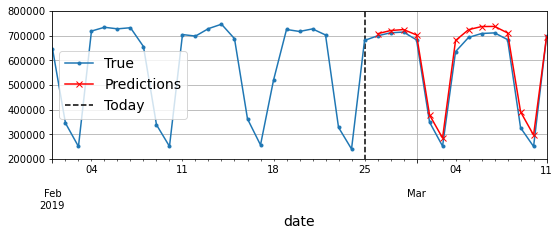

In [50]:
# extra code – generates and saves Figure 15–11

# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred = pd.Series(X[0, -14:, 0],
                   index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
save_fig("forecast_ahead_plot")
plt.show()

Now let's create an RNN that predicts all 14 next values at once:

In [51]:
tf.random.set_seed(42)  # extra code – ensures reproducibility

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets)
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [52]:
tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [53]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 [==============================] - 1s 12ms/step - loss: 0.1250 - mae: 0.3791 - val_loss: 0.0287 - val_mae: 0.1935
Epoch 2/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0191 - mae: 0.1613 - val_loss: 0.0136 - val_mae: 0.1289
Epoch 3/500
33/33 [==============================] - 0s 8ms/step - loss: 0.0131 - mae: 0.1303 - val_loss: 0.0102 - val_mae: 0.1113
Epoch 4/500
33/33 [==============================] - 0s 8ms/step - loss: 0.0108 - mae: 0.1164 - val_loss: 0.0083 - val_mae: 0.1009
Epoch 5/500
33/33 [==============================] - 0s 8ms/step - loss: 0.0093 - mae: 0.1068 - val_loss: 0.0071 - val_mae: 0.0931
Epoch 6/500
33/33 [==============================] - 0s 8ms/step - loss: 0.0083 - mae: 0.0996 - val_loss: 0.0061 - val_mae: 0.0862
Epoch 7/500
33/33 [==============================] - 0s 9ms/step - loss: 0.0076 - mae: 0.0941 - val_loss: 0.0055 - val_mae: 0.0811
Epoch 8/500
33/33 [==============================] - 0s 8ms/step - loss: 0.0072 - 

35017.29667186737

In [54]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  # shape [1, 56, 5]
Y_pred = ahead_model.predict(X)  # shape [1, 14]

Now let's create an RNN that predicts the next 14 steps at each time step. That is, instead of just forecasting time steps 56 to 69 based on time steps 0 to 55, it will forecast time steps 1 to 14 at time step 0, then time steps 2 to 15 at time step 1, and so on, and finally it will forecast time steps 56 to 69 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

To prepare the datasets, we can use `to_windows()` twice, to get sequences of consecutive windows, like this:

In [55]:
my_series = tf.data.Dataset.range(7)
dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])>]

Then we can split these elements into the desired inputs and targets:

In [56]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]])>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]])>)]

Let's wrap this idea into a utility function. It will also take care of shuffling (optional) and batching:

In [57]:
def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                       batch_size=32, shuffle=False, seed=None):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(
        lambda S: (S[:, 0], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

In [58]:
seq2seq_train = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(mulvar_valid)

In [59]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
    # equivalent: tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(14))
    # also equivalent: tf.keras.layers.Conv1D(14, kernel_size=1)
])

In [60]:
fit_and_evaluate(seq2seq_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1)

Epoch 1/500
33/33 [==============================] - 1s 17ms/step - loss: 0.0754 - mae: 0.2785 - val_loss: 0.0163 - val_mae: 0.1379
Epoch 2/500
33/33 [==============================] - 0s 11ms/step - loss: 0.0097 - mae: 0.1050 - val_loss: 0.0071 - val_mae: 0.0853
Epoch 3/500
33/33 [==============================] - 0s 11ms/step - loss: 0.0069 - mae: 0.0846 - val_loss: 0.0063 - val_mae: 0.0790
Epoch 4/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0060 - mae: 0.0773 - val_loss: 0.0056 - val_mae: 0.0729
Epoch 5/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0055 - mae: 0.0722 - val_loss: 0.0049 - val_mae: 0.0662
Epoch 6/500
33/33 [==============================] - 0s 10ms/step - loss: 0.0052 - mae: 0.0690 - val_loss: 0.0051 - val_mae: 0.0683
Epoch 7/500
33/33 [==============================] - 0s 11ms/step - loss: 0.0049 - mae: 0.0663 - val_loss: 0.0046 - val_mae: 0.0626
Epoch 8/500
33/33 [==============================] - 0s 11ms/step - loss: 0.

45928.88057231903

In [61]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]  # only the last time step's output

In [62]:
Y_pred_valid = seq2seq_model.predict(seq2seq_valid)
for ahead in range(14):
    preds = pd.Series(Y_pred_valid[:-1, -1, ahead],
                      index=mulvar_valid.index[56 + ahead : -14 + ahead])
    mae = (preds - mulvar_valid["rail"]).abs().mean() * 1e6
    print(f"MAE for +{ahead + 1}: {mae:,.0f}")

MAE for +1: 25,519
MAE for +2: 26,274
MAE for +3: 27,054
MAE for +4: 29,324
MAE for +5: 28,992
MAE for +6: 31,739
MAE for +7: 32,847
MAE for +8: 33,282
MAE for +9: 33,072
MAE for +10: 29,752
MAE for +11: 37,468
MAE for +12: 35,125
MAE for +13: 34,614
MAE for +14: 34,322


# Deep RNNs with Layer Norm

In [63]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units,
                                                             activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [64]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
custom_ln_model = tf.keras.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True,
                        input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [65]:
fit_and_evaluate(custom_ln_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 [==============================] - 2s 25ms/step - loss: 0.0809 - mae: 0.2898 - val_loss: 0.0178 - val_mae: 0.1511
Epoch 2/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0149 - mae: 0.1438 - val_loss: 0.0156 - val_mae: 0.1245
Epoch 3/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0120 - mae: 0.1281 - val_loss: 0.0131 - val_mae: 0.1160
Epoch 4/5
33/33 [==============================] - 1s 17ms/step - loss: 0.0105 - mae: 0.1167 - val_loss: 0.0118 - val_mae: 0.1095
Epoch 5/5
3/3 [==============================] - 0s 14ms/step - loss: 0.0105 - mae: 0.1038


103751.08569860458

# Extra Material – Creating a Custom RNN Class

The RNN class is not magical. In fact, it's not too hard to implement your own RNN class:

In [66]:
class MyRNN(tf.keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences

    def get_initial_state(self, inputs):
        try:
            return self.cell.get_initial_state(inputs)
        except AttributeError:
            # fallback to zeros if self.cell has no get_initial_state() method
            batch_size = tf.shape(inputs)[0]
            return [tf.zeros([batch_size, self.cell.state_size],
                             dtype=inputs.dtype)]

    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size],
                           dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)

        if self.return_sequences:
            # stack the outputs into an array of shape
            # [time steps, batch size, dims], then transpose it to shape
            # [batch size, time steps, dims]
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs

Note that `@tf.function` requires the `outputs` variable to be created before the `for` loop, which is why we initialize its value to a zero tensor, even though we don't use that value at all. Once the function is converted to a graph, this unused value will be pruned from the graph, so it doesn't impact performance. Similarly, `@tf.function` requires the `sequences` variable to be created before the `if` statement where it is used, even if `self.return_sequences` is `False`, so we create a `TensorArray` of size 0 in this case.

In [67]:
tf.random.set_seed(42)

custom_model = tf.keras.Sequential([
    MyRNN(LNSimpleRNNCell(32), return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [68]:
fit_and_evaluate(custom_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 [==============================] - 2s 26ms/step - loss: 0.0814 - mae: 0.2916 - val_loss: 0.0176 - val_mae: 0.1544
Epoch 2/5
33/33 [==============================] - 1s 20ms/step - loss: 0.0151 - mae: 0.1440 - val_loss: 0.0157 - val_mae: 0.1247
Epoch 3/5
33/33 [==============================] - 1s 19ms/step - loss: 0.0119 - mae: 0.1281 - val_loss: 0.0134 - val_mae: 0.1160
Epoch 4/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0105 - mae: 0.1162 - val_loss: 0.0111 - val_mae: 0.1084
Epoch 5/5
3/3 [==============================] - 0s 14ms/step - loss: 0.0103 - mae: 0.1029


102874.92722272873

# LSTMs

In [69]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [70]:
fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 [==============================] - 2s 29ms/step - loss: 0.0535 - mae: 0.2517 - val_loss: 0.0187 - val_mae: 0.1716
Epoch 2/5
33/33 [==============================] - 1s 16ms/step - loss: 0.0176 - mae: 0.1598 - val_loss: 0.0176 - val_mae: 0.1473
Epoch 3/5
33/33 [==============================] - 1s 16ms/step - loss: 0.0160 - mae: 0.1528 - val_loss: 0.0168 - val_mae: 0.1433
Epoch 4/5
33/33 [==============================] - 1s 16ms/step - loss: 0.0152 - mae: 0.1485 - val_loss: 0.0161 - val_mae: 0.1388
Epoch 5/5
3/3 [==============================] - 0s 14ms/step - loss: 0.0154 - mae: 0.1352


135186.25497817993

# GRUs

In [71]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [72]:
fit_and_evaluate(gru_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 [==============================] - 2s 29ms/step - loss: 0.0516 - mae: 0.2489 - val_loss: 0.0165 - val_mae: 0.1529
Epoch 2/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0145 - mae: 0.1386 - val_loss: 0.0139 - val_mae: 0.1260
Epoch 3/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0118 - mae: 0.1249 - val_loss: 0.0121 - val_mae: 0.1170
Epoch 4/5
33/33 [==============================] - 1s 18ms/step - loss: 0.0106 - mae: 0.1166 - val_loss: 0.0111 - val_mae: 0.1109
Epoch 5/5
3/3 [==============================] - 0s 14ms/step - loss: 0.0104 - mae: 0.1071


107093.29694509506

## Using One-Dimensional Convolutional Layers to Process Sequences

```
  |-----0-----|      |-----3----|      |--... |-------52------|
         |-----1----|      |-----4----|   ... |       |-------53------|
               |-----2----|     |------5--...-51------|       |-------54------|
X:  0  1  2  3  4  5  6  7  8  9 10 11 12 ...  104 105 106 107 108 109 110 111
Y:      from 4     6     8    10    12    ...      106     108     110     112
         to 17    19    21    23    25    ...      119     121     123     125
```

In [73]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
conv_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2,
                           activation="relu", input_shape=[None, 5]),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112,
                                       shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)
downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

Just training for 5 epochs to show that it works (you can increase this if you want):

In [74]:
fit_and_evaluate(conv_rnn_model, downsampled_train, downsampled_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 [==============================] - 2s 30ms/step - loss: 0.0482 - mae: 0.2420 - val_loss: 0.0214 - val_mae: 0.1616
Epoch 2/5
31/31 [==============================] - 1s 18ms/step - loss: 0.0165 - mae: 0.1532 - val_loss: 0.0171 - val_mae: 0.1423
Epoch 3/5
31/31 [==============================] - 1s 18ms/step - loss: 0.0144 - mae: 0.1447 - val_loss: 0.0157 - val_mae: 0.1342
Epoch 4/5
31/31 [==============================] - 1s 17ms/step - loss: 0.0130 - mae: 0.1361 - val_loss: 0.0141 - val_mae: 0.1254
Epoch 5/5
1/1 [==============================] - 0s 88ms/step - loss: 0.0124 - mae: 0.1159


115850.42625665665

## WaveNet

```
 ⋮
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\...
   \  /  \  /  \  /  \  /  \  /  \  /  \     
     /    \      /    \      /    \          
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /...\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 111
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 112
 /14 15 16 17 18 19 20 21 22  23 24 25 26 ... 125
```

In [75]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
wavenet_model = tf.keras.Sequential()
wavenet_model.add(tf.keras.layers.InputLayer(input_shape=[None, 5]))
for rate in (1, 2, 4, 8) * 2:
    wavenet_model.add(tf.keras.layers.Conv1D(
        filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))
wavenet_model.add(tf.keras.layers.Conv1D(filters=14, kernel_size=1))

Just training for 5 epochs to show that it works (you can increase this if you want):

In [76]:
fit_and_evaluate(wavenet_model, longer_train, longer_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 [==============================] - 2s 26ms/step - loss: 0.0796 - mae: 0.3159 - val_loss: 0.0239 - val_mae: 0.1723
Epoch 2/5
31/31 [==============================] - 1s 16ms/step - loss: 0.0172 - mae: 0.1585 - val_loss: 0.0182 - val_mae: 0.1545
Epoch 3/5
31/31 [==============================] - 1s 16ms/step - loss: 0.0159 - mae: 0.1561 - val_loss: 0.0181 - val_mae: 0.1505
Epoch 4/5
31/31 [==============================] - 1s 16ms/step - loss: 0.0155 - mae: 0.1535 - val_loss: 0.0175 - val_mae: 0.1479
Epoch 5/5
1/1 [==============================] - 0s 74ms/step - loss: 0.0166 - mae: 0.1407


140713.95993232727

# Extra Material – Wavenet Implementation

Here is the original WaveNet defined in the paper: it uses Gated Activation Units instead of ReLU and parametrized skip connections, plus it pads with zeros on the left to avoid getting shorter and shorter sequences:

In [77]:
class GatedActivationUnit(tf.keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = tf.keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [78]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = tf.keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = tf.keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return tf.keras.layers.Add()([z, inputs]), z

In [79]:
tf.random.set_seed(42)

n_layers_per_block = 3  # 10 in the paper
n_blocks = 1  # 3 in the paper
n_filters = 32  # 128 in the paper
n_outputs = 14  # 256 in the paper

inputs = tf.keras.layers.Input(shape=[None, 5])
z = tf.keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)

z = tf.keras.activations.relu(tf.keras.layers.Add()(skip_to_last))
z = tf.keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_preds = tf.keras.layers.Conv1D(n_outputs, kernel_size=1)(z)

full_wavenet_model = tf.keras.Model(inputs=[inputs], outputs=[Y_preds])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [80]:
fit_and_evaluate(full_wavenet_model, longer_train, longer_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 [==============================] - 2s 26ms/step - loss: 0.0706 - mae: 0.2861 - val_loss: 0.0209 - val_mae: 0.1630
Epoch 2/5
31/31 [==============================] - 1s 18ms/step - loss: 0.0137 - mae: 0.1398 - val_loss: 0.0140 - val_mae: 0.1273
Epoch 3/5
31/31 [==============================] - 1s 20ms/step - loss: 0.0104 - mae: 0.1190 - val_loss: 0.0116 - val_mae: 0.1125
Epoch 4/5
31/31 [==============================] - 1s 18ms/step - loss: 0.0086 - mae: 0.1048 - val_loss: 0.0096 - val_mae: 0.1020
Epoch 5/5
1/1 [==============================] - 0s 71ms/step - loss: 0.0087 - mae: 0.0953


95349.08086061478